Visualize the predefined and random floorplans

In [1]:
#%xmode minimal

In [2]:
from pathlib import Path
from matplotlib import pyplot as plt
from typing import cast
from yaml import safe_load
from shapely import Polygon, LineString, ops, plotting, equals
import numpy as np
from shutil import copytree, rmtree
import h5py

import modules.read_wi_files as rwf
import modules.project as p
import modules.project_creation as pc
import modules.write_wi_files as wwf
import modules.utils as u

import warnings

# Ignore all UserWarnings globally
warnings.filterwarnings("ignore", category=UserWarning)


# Original room

added table_surface43
added chair45_legs
added chair22_legs
added chair24_legs
added blackboard
added chair0
added lamp1
added chair31_legs
added chair41_legs
added chair26_legs
added radiator2
added chair14_legs
added chair42_legs
added table_surface33
added table_surface12
added chair15_legs
added table_surface22
added chair43_legs
added chair33_legs
added chair21_legs
added table_surface
added table_surface23
added chair32_legs
added cables
added table_surface13
added radiator1
added radiator4
added lamp2
added table_surface21
added chair36_legs
added table_surface32
added radiator3
added chair13_legs
added chair34_legs
added table_surface11
added table_small
added lamp3
added chair16_legs
added whiteboard
added table_surface41
added chair46_legs
added chair25_legs
added chair12_legs
added chair12_legs(2)
added chair35_legs
added chair44_legs
added radiator5
added chair11_legs
added table_surface31
added chair23_legs
added table_surface42
added cabinet


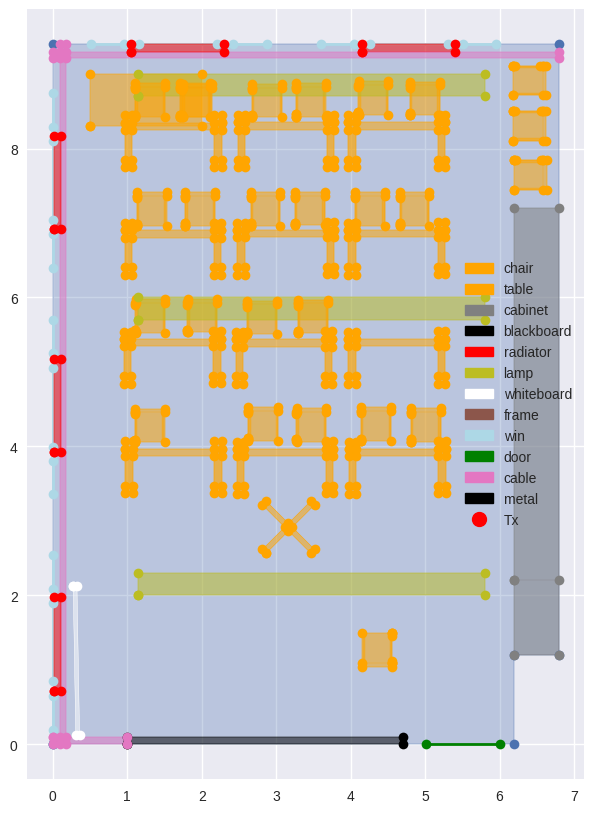

In [ ]:
# Load original floorplan and objects
project_dir = Path('./wi_project_files_complete')
flp_file = next(iter(project_dir.rglob("*flp")))
flp_orig = rwf.create_floorplan_from_file(flp_file, 4)
 
objects_orig = []
for obj_file in project_dir.glob('*.object'):
    objects_orig.append(rwf.create_object_from_file(obj_file))
    print(f'added {obj_file.stem}')

# Plot original room
import warnings 
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning, append=True)
    _ = p.plot_room(flp_orig, objects_orig, tx_list=[])

# Random room with some objects, write to files

Create a random room from a config and plot it

managed to place 1 / 1 instances of cabinet in walls with 0 frames
managed to place 4 / 4 instances of radiator in walls with 0 frames
managed to place 1 / 1 instances of cable_tunnel in walls with 0 frames
managed to place 0 / 0 instances of blackboard in walls with 0 frames
managed to place 1 / 1 instances of door in walls with 0 frames
managed to place 8 / 8 instances of window in walls with 6 frames
managed to place 12 / 12 instances of metal_plate in walls with 0 frames
managed to place 7 / 7 instances of table_chair_group
managed to place 3 / 3 instances of chair
managed to place 0 / 0 instances of table_small
managed to place 0 / 0 instances of table_big
managed to place 3 / 3 instances of lamp
managed to place 1 / 1 instances of whiteboard
created project with 44 things inside the walls and 20 objects
managed to place 5 / 5 instances of tx


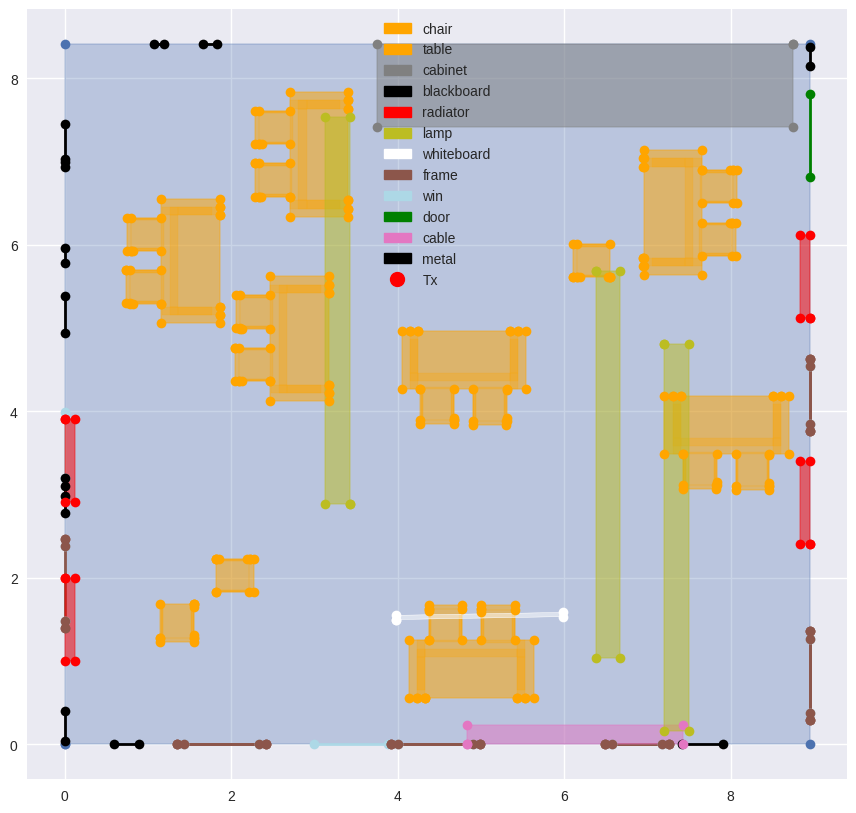

In [5]:
cfg_path = 'configs/config1.yml'

with open(cfg_path, 'r') as f:
    cfg = safe_load(f)


project, cfg_updated = pc.create_project_randomly(cfg, verbose=True)

_ = p.plot_project(project=project)

# Inspect the processed data

In [14]:
import yaml

project_raster_dir = Path('./indoor_projects_filtered_250922/rasterized_projects_256x256')
radio_map_dir = project_raster_dir.parent / 'radio_maps_-12_-71'
cfg_dir = project_raster_dir.parent / 'simulation_data'

radio_map_files = list(radio_map_dir.glob('*.png'))
project_raster_files = list(project_raster_dir.glob('*.png'))

print(len(radio_map_files), len(project_raster_files))

18005 5057716


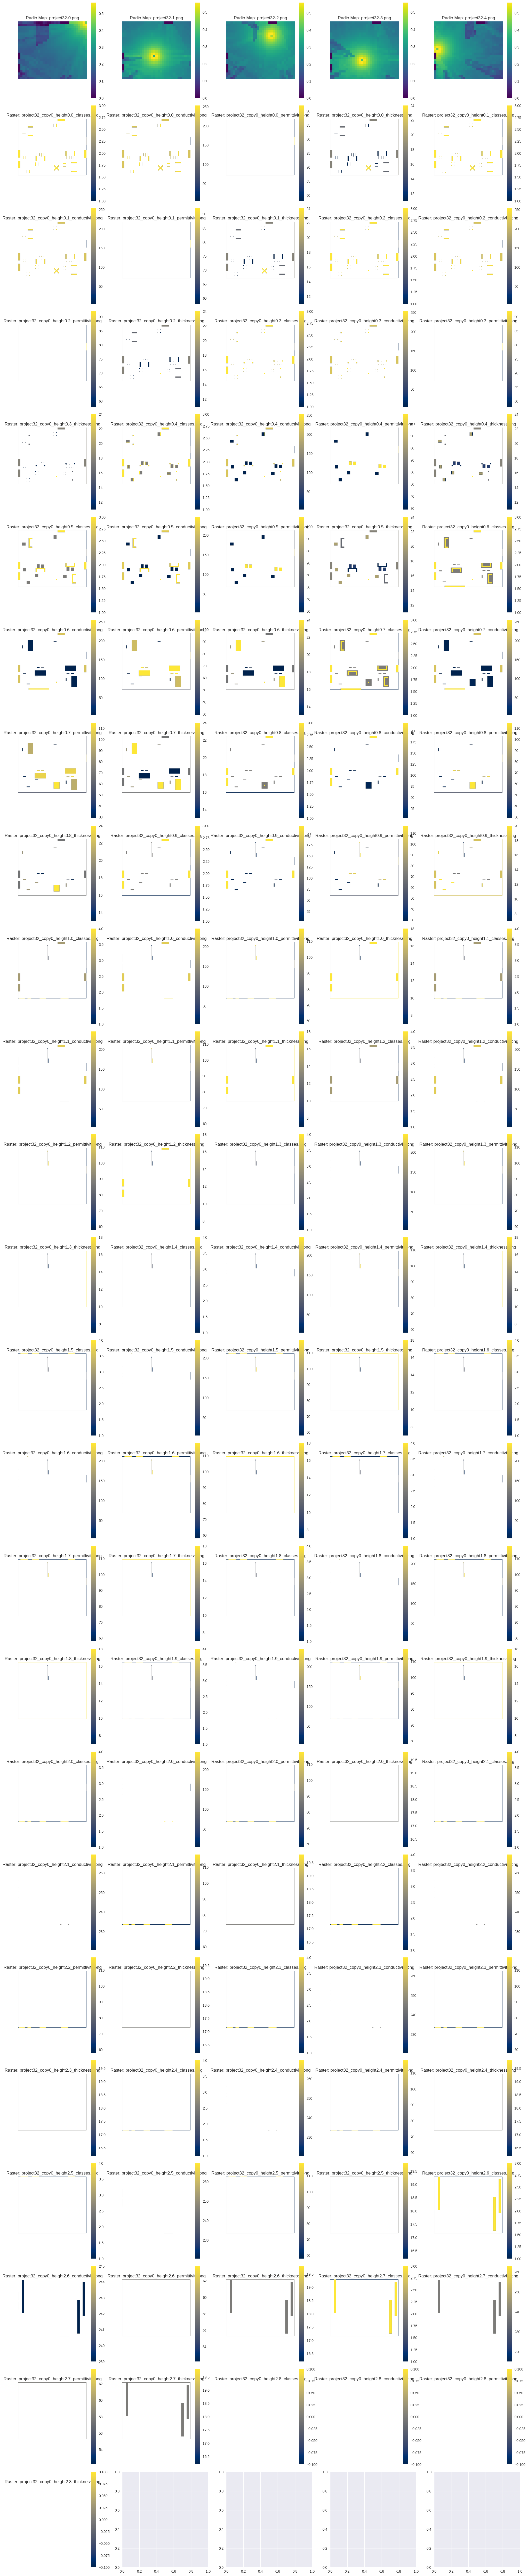

In [22]:


for _ in range(2):

    project_id = np.random.randint(0, 2000)

    rms_here = sorted([r for r in radio_map_files if f'project{project_id}-' in r.stem])
    rasters_here1 = sorted([r for r in project_raster_files if f'project{project_id}_copy0' in r.stem])
    if len(rms_here)==0:
        continue

    n_plots = len(rms_here) + len(rasters_here1) 
    ncols = 5
    nrows = (n_plots + ncols - 1) // ncols  
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 4))
    axes = axes.flatten()

    ### radio maps
    for i, rm_file in enumerate(rms_here):
        ax = axes[i]
        img = plt.imread(rm_file)
        im = ax.imshow(img, cmap='viridis')
        ax.set_title(f"Radio Map: {rm_file.name}")
        ax.axis('off')
        fig.colorbar(im, ax=ax)

    ### env rasters
    for i, rast_file in enumerate(rasters_here1, start=len(rms_here)):
        ax = axes[i]
        img = 255 * plt.imread(rast_file)
        im = ax.imshow(np.where(img > 0, img, np.nan), cmap='cividis')
        ax.set_title(f"Raster: {rast_file.name}")
        ax.axis('off')
        fig.colorbar(im, ax=ax)



    plt.tight_layout()
    plt.show()